# OUTTHERE per-field HDF5 check

This notebook is used to:
1) verify dependencies in the astronino/astrodino environment;
2) run the export script on a small sample (by field + limit);
3) read back the generated `.h5` and inspect keys/shape/mask coverage, and visualize one sample.

By default, it assumes you run it in the `images/OUTTHERE/` directory.

In [2]:
import sys, platform
import numpy as np
import h5py
import astropy
import matplotlib
print('python:', sys.version)
print('platform:', platform.platform())
print('numpy:', np.__version__)
print('h5py:', h5py.__version__)
print('astropy:', astropy.__version__)
print('matplotlib:', matplotlib.__version__)

python: 3.13.9 | packaged by conda-forge | (main, Oct 22 2025, 23:33:35) [GCC 14.3.0]
platform: Linux-6.4.0-150600.23.78-default-x86_64-with-glibc2.38
numpy: 2.3.4
h5py: 3.15.1
astropy: 7.1.1
matplotlib: 3.10.7


In [3]:
from pathlib import Path
import subprocess

# Paths and parameters (edit as needed)
BASE = Path('.').resolve()
EXPORTER = BASE / 'export_outthere_h5.py'
OUT_DIR = BASE / 'outputs' / 'h5_test_sex09'
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIELD = 'sex-09'  # Choose a field with more complete data
LIMIT = 30        # Small sample for testing

# The exporter reads spectra-fitting.fits and data/ next to itself
SCRIPT_DIR = EXPORTER.resolve().parent
MASTER = SCRIPT_DIR / 'spectra-fitting.fits'
DATA_DIR = SCRIPT_DIR / 'data'

print('BASE:', BASE)
print('EXPORTER exists:', EXPORTER.exists(), EXPORTER)
print('MASTER exists:', MASTER.exists(), MASTER)
print('DATA_DIR exists:', DATA_DIR.exists(), DATA_DIR)
print('OUT_DIR:', OUT_DIR)

BASE: /raven/u/yacheng/projects/ssl_outthere/images/OUTTHERE
EXPORTER exists: True /raven/u/yacheng/projects/ssl_outthere/images/OUTTHERE/export_outthere_h5.py
MASTER exists: True /raven/u/yacheng/projects/ssl_outthere/images/OUTTHERE/spectra-fitting.fits
DATA_DIR exists: True /raven/u/yacheng/projects/ssl_outthere/images/OUTTHERE/data
OUT_DIR: /raven/u/yacheng/projects/ssl_outthere/images/OUTTHERE/outputs/h5_test_sex09


In [5]:
# Read the generated H5 and check structure/shape/mask coverage
h5_path = OUT_DIR / f'{FIELD}.h5'
assert h5_path.exists(), f'missing {h5_path}'
print('H5:', h5_path)

with h5py.File(h5_path, 'r') as h5:
    keys = sorted(list(h5.keys()))
    print('top-level keys:', keys)
    print('attrs:', dict(h5.attrs))
    
    def shape_of(k):
        o = h5[k]
        return o.shape if hasattr(o, 'shape') else None
    
    for k in keys:
        print(f'{k:20s}', type(h5[k]).__name__, shape_of(k), getattr(h5[k], 'dtype', None))
    
    N = int(h5['id'].shape[0])
    print('N =', N)
    
    # Coverage statistics
    for f in ['f115w','f150w','f200w']:
        img_mask = h5[f'{f}_img_mask'][:]
        spec_mask = h5[f'{f}_spec_mask'][:]
        print(f'{f}: img_cov={img_mask.mean():.3f} spec_cov={spec_mask.mean():.3f}')
        print('dim of spectrum:', h5[f'{f}_flux'].shape[1])

H5: /raven/u/yacheng/projects/ssl_outthere/images/OUTTHERE/outputs/h5_test_sex09/sex-09.h5
top-level keys: ['f115w', 'f115w_contam', 'f115w_err', 'f115w_flux', 'f115w_img_mask', 'f115w_line', 'f115w_spec_mask', 'f115w_spec_sn', 'f115w_wave', 'f150w', 'f150w_contam', 'f150w_err', 'f150w_flux', 'f150w_img_mask', 'f150w_line', 'f150w_spec_mask', 'f150w_spec_sn', 'f150w_wave', 'f200w', 'f200w_contam', 'f200w_err', 'f200w_flux', 'f200w_img_mask', 'f200w_line', 'f200w_spec_mask', 'f200w_spec_sn', 'f200w_wave', 'field', 'id', 'seg']
attrs: {'cutout_size': np.int64(128), 'field': 'sex-09', 'fill_value': np.float64(-99.0), 'filters': array(['F115W', 'F150W', 'F200W'], dtype=object), 'image_extname': 'DSCI'}
f115w                Dataset (30, 128, 128) float32
f115w_contam         Dataset (30, 79) float32
f115w_err            Dataset (30, 79) float32
f115w_flux           Dataset (30, 79) float32
f115w_img_mask       Dataset (30,) uint8
f115w_line           Dataset (30, 79) float32
f115w_spec_mask

random pick index: 17 id: 85 fill_value: -99.0


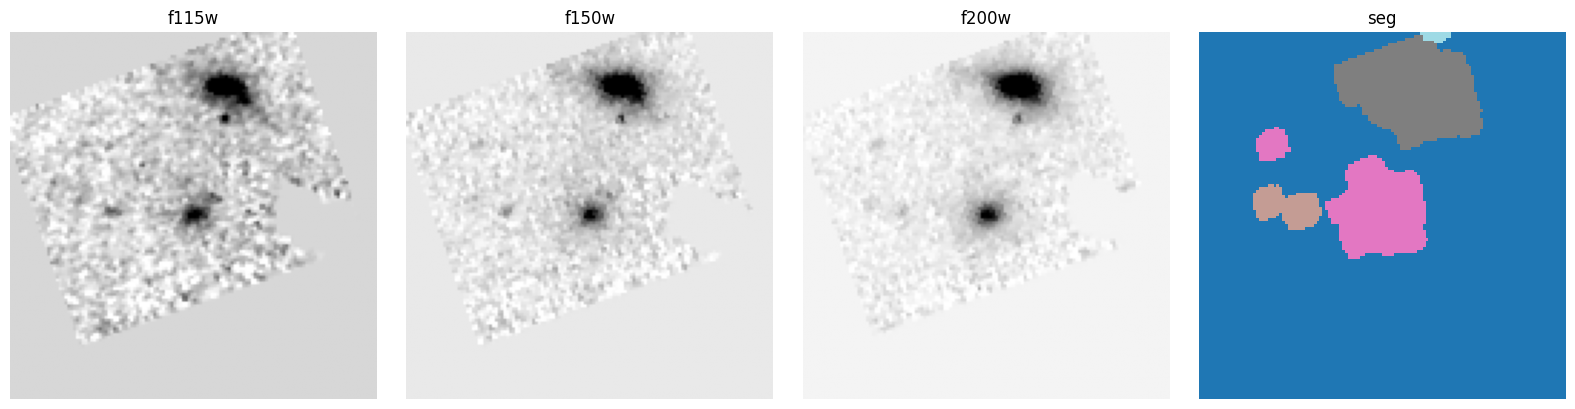

sn of spcectrum f115w: 3.6863484
sn of spcectrum f150w: 2.9106545
sn of spcectrum f200w: 2.762615


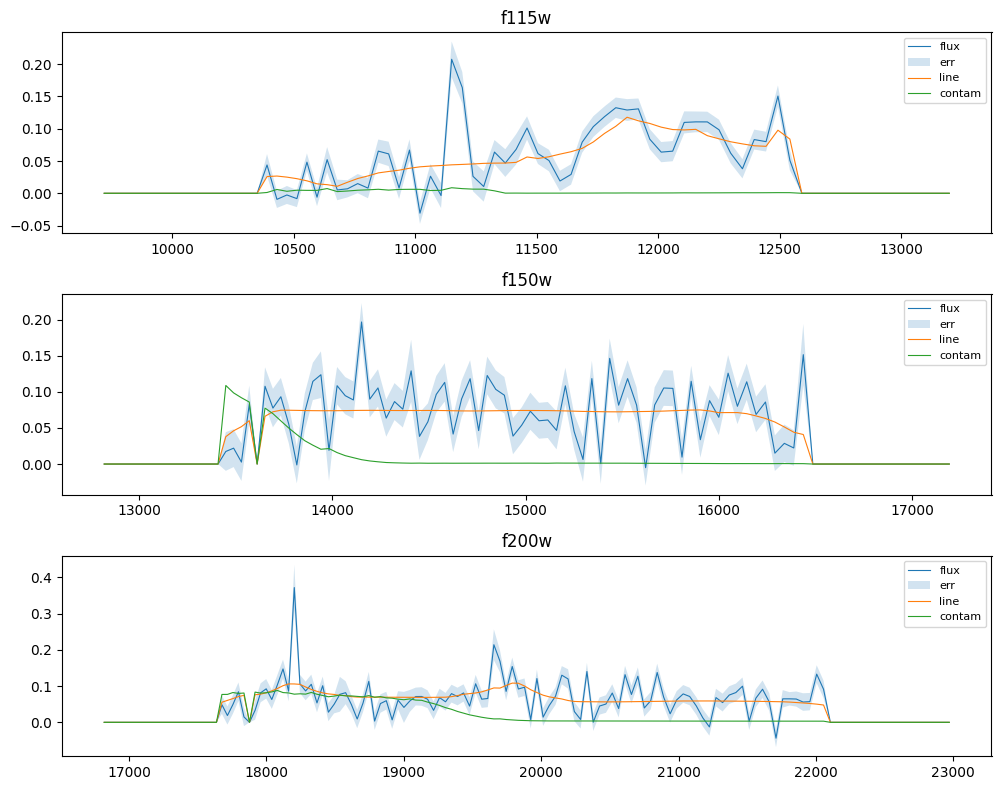

In [56]:
# Visualize a sample with data (missing values use fill_value=-99)
import matplotlib.pyplot as plt

with h5py.File(h5_path, 'r') as h5:
    fill = float(h5.attrs.get('fill_value', -99.0))
    N = int(h5['id'].shape[0])
    # Find a sample with both f150w image + spectrum (otherwise relax the condition)
    ok = np.where((h5['f150w_img_mask'][:] == 1) & (h5['f150w_spec_mask'][:] == 1))[0]
    if len(ok) == 0:
        ok = np.where(h5['f150w_spec_mask'][:] == 1)[0]
    assert len(ok) > 0, 'no valid examples found in this sample'
    
    rng = np.random.default_rng()
    i = int(rng.choice(ok))
    oid = int(h5['id'][i])
    print('random pick index:', i, 'id:', oid, 'fill_value:', fill)
    
    # Plot 3 bands + segmentation map
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, f in zip(axes[:3], ['f115w','f150w','f200w']):
        img = h5[f][i]
        v = img[img != fill]
        if v.size > 0:
            vmin = np.percentile(v, 2)
            vmax = np.percentile(v, 99.5)
        else:
            vmin, vmax = None, None
        ax.imshow(img, origin='lower', cmap='gray_r', vmin=vmin, vmax=vmax)
        ax.set_title(f)
        ax.axis('off')
    
    seg = h5['seg'][i]
    axes[3].imshow(seg, origin='lower', cmap='tab20', interpolation='nearest')
    axes[3].set_title('seg')
    axes[3].axis('off')
    plt.tight_layout()
    plt.show()
    
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=False)
    for ax, f in zip(axes, ['f115w','f150w','f200w']):
        wave = h5[f'{f}_wave'][i]
        flux = h5[f'{f}_flux'][i]
        err  = h5[f'{f}_err'][i]
        line = h5[f'{f}_line'][i]
        contam = h5[f'{f}_contam'][i]
        print(f'sn of spcectrum {f}:',h5[f'{f}_spec_sn'][i])
        m = (wave != fill) & (flux != fill)
        ax.plot(wave[m], flux[m], lw=0.8, label='flux')
        ax.fill_between(wave[m], (flux-err)[m], (flux+err)[m], alpha=0.2, label='err')
        ax.plot(wave[m], line[m], lw=0.8, label='line')
        ax.plot(wave[m], contam[m], lw=0.8, label='contam')
        ax.set_title(f)
        ax.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()